In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [26]:
# 1. Lade den Datensatz
file_path = "synthetic_survey_data_NoNaNs_100.csv"  # Pfad ggf. anpassen
df = pd.read_csv(file_path)
df

,Q1,Q2A,Q2B,Q2C,Q2D,Q2E,Q2F,Q2G,Q4A,Q4B,...,Q12I,Q13,Q14,Q15,Q16,Q17A,Q17B,Q17C,Q17D,Q17E
0,5.0,2.0,2.0,2.0,2.0,1.0,3.0,1.0,2.0,3.0,...,2.0,1.0,11.0,4.0,1.0,1.0,0.0,1.0,0.0,0.0
1,4.0,2.0,2.0,2.0,1.0,3.0,3.0,3.0,2.0,3.0,...,4.0,2.0,8.0,3.0,3.0,1.0,0.0,0.0,1.0,0.0
2,3.0,1.0,1.0,2.0,2.0,3.0,3.0,1.0,3.0,2.0,...,3.0,2.0,8.0,15.0,2.0,1.0,0.0,1.0,0.0,1.0
3,5.0,3.0,2.0,1.0,1.0,1.0,1.0,1.0,2.0,3.0,...,2.0,1.0,11.0,5.0,1.0,1.0,0.0,1.0,1.0,1.0
4,2.0,2.0,2.0,2.0,2.0,3.0,2.0,3.0,1.0,2.0,...,3.0,2.0,12.0,1.0,2.0,0.0,1.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,1.0,3.0,3.0,2.0,2.0,3.0,3.0,2.0,2.0,2.0,...,3.0,2.0,11.0,1.0,2.0,1.0,1.0,1.0,1.0,1.0
496,5.0,3.0,1.0,2.0,2.0,3.0,2.0,3.0,2.0,3.0,...,2.0,2.0,7.0,17.0,1.0,1.0,0.0,1.0,0.0,0.0
497,2.0,3.0,2.0,1.0,1.0,2.0,3.0,2.0,2.0,2.0,...,1.0,1.0,3.0,2.0,1.0,0.0,0.0,0.0,1.0,0.0
498,4.0,2.0,2.0,1.0,2.0,3.0,2.0,3.0,2.0,2.0,...,3.0,1.0,13.0,4.0,2.0,0.0,0.0,0.0,1.0,0.0


In [27]:
# 2. Liste der Genussvariablen laut Vorgabe
genuss_variablen = [
    "Q2C", "Q2D", "Q6C", "Q7A", "Q7C", "Q8A", "Q8B", "Q8C", "Q8E", "Q8G", "Q8J",
    "Q9A", "Q9B", "Q9C", "Q9D", "Q9E", "Q9F", "Q9G", "Q9H", "Q9I", "Q9J", "Q9K", "Q9L",
    "Q10A", "Q11A", "Q11B", "Q11C", "Q11D", "Q11E", "Q11F", "Q11G", "Q11H", "Q11I",
    "Q12G"
]

In [28]:
# 3. Filtere den Datensatz auf die Genussvariablen
df_genuss = df[genuss_variablen]

In [29]:
# 4. Berechne den Mittelwert jeder Variable (Sensorprofil)
means = df_genuss.mean().round(2)

In [30]:
# 5. Erstelle Radar Chart (Sensorbild)
labels = means.index.tolist()
values = means.values.tolist()

In [31]:
# Wiederhole den ersten Wert, um den Kreis zu schließen
values += values[:1]
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]

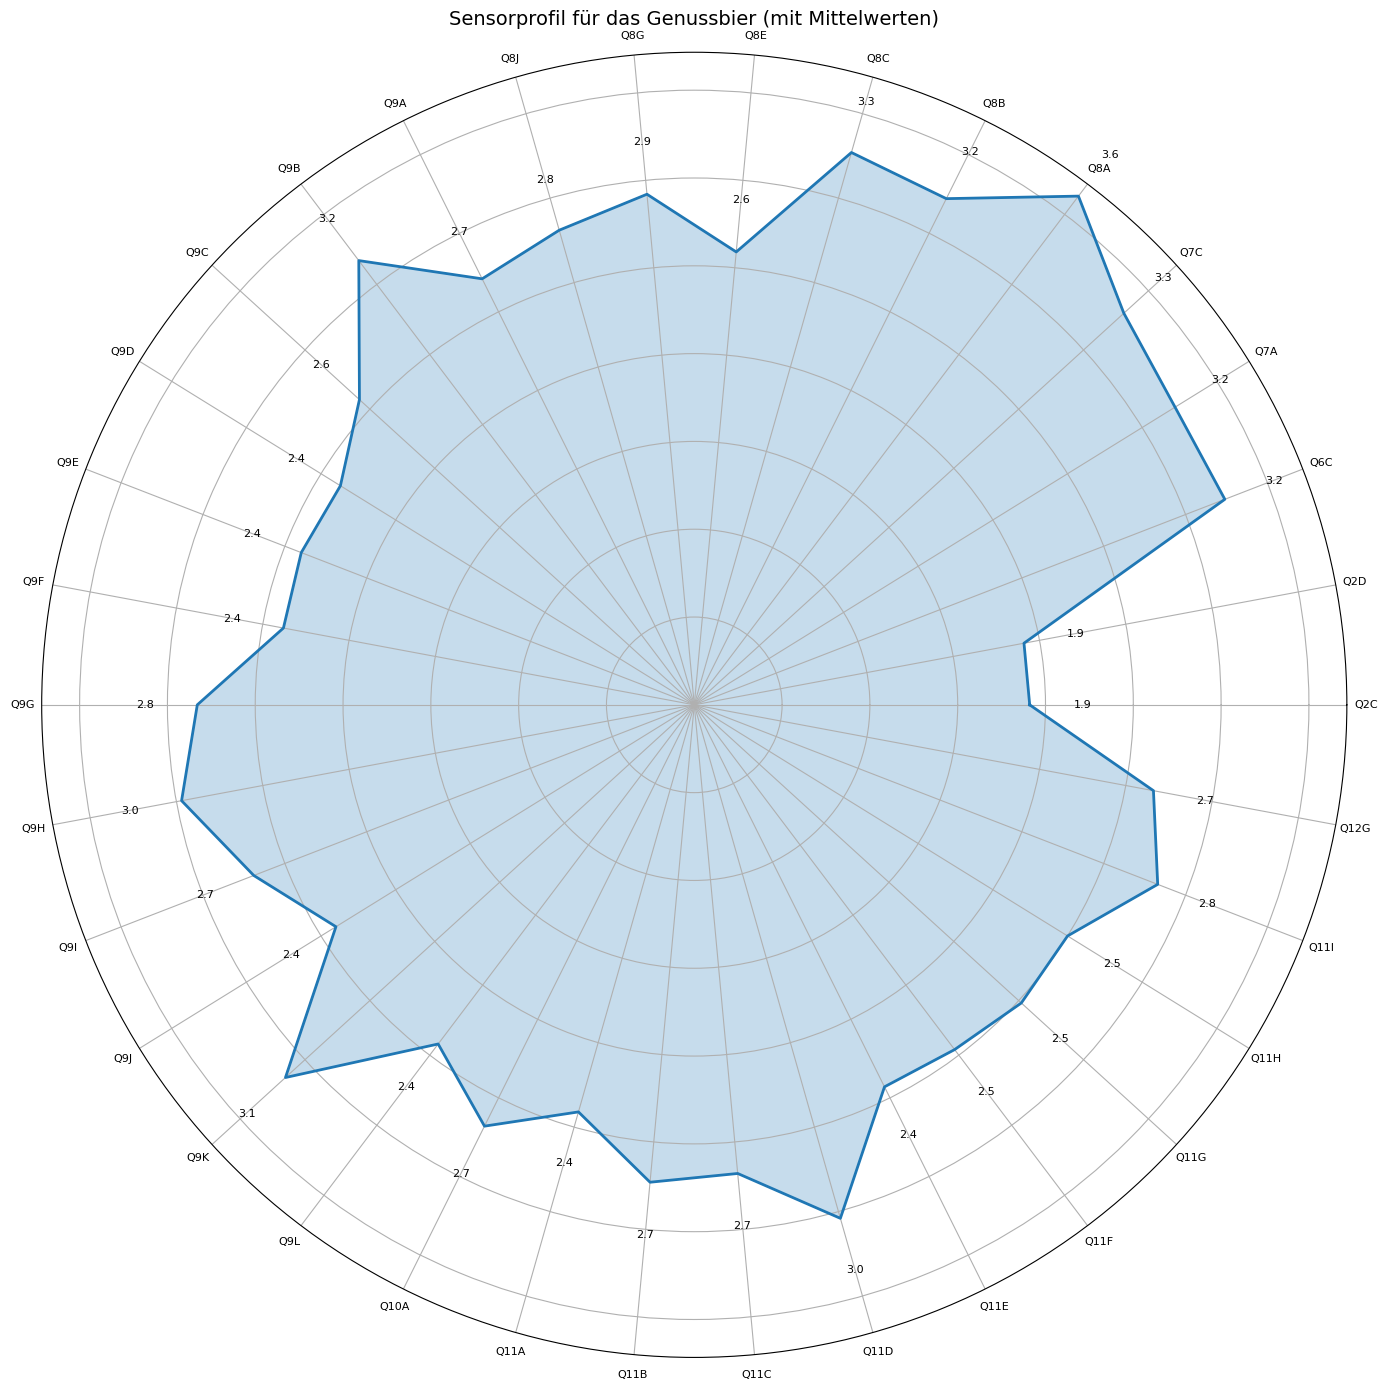

In [32]:
# 6. Radar-Plot erzeugen
fig, ax = plt.subplots(figsize=(14, 14), subplot_kw=dict(polar=True))
ax.plot(angles, values, linewidth=2, color='tab:blue')
ax.fill(angles, values, alpha=0.25, color='tab:blue')

# Achsenticks und -beschriftung
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=8, rotation=90)
ax.set_yticklabels([])

# Werte an den Punkten anzeigen
for i, (angle, value) in enumerate(zip(angles, values)):
    if i < len(labels):  # das letzte ist nur zur Kreis-Schließung
        ax.text(angle, value + 0.3, f"{value:.1f}", ha='center', va='center', fontsize=8, color='black')

# Titel setzen
ax.set_title("Sensorprofil für das Genussbier (mit Mittelwerten)", size=14, pad=20)
plt.savefig("sensorprofil_genussbier.png", dpi=300)
plt.tight_layout()
plt.show()

In [33]:

# Geschmackskategorien laut Umfrage (Fragen Q11A bis Q11I)
geschmacksfragen = {
    "Q11A": "rauchig",
    "Q11B": "herb-hopfig",
    "Q11C": "süßlich-malz",
    "Q11D": "fruchtig",
    "Q11E": "kräutrig",
    "Q11F": "gewürzartig",
    "Q11G": "bitter",
    "Q11H": "säuerlich",
    "Q11I": "zitrusartig"
}

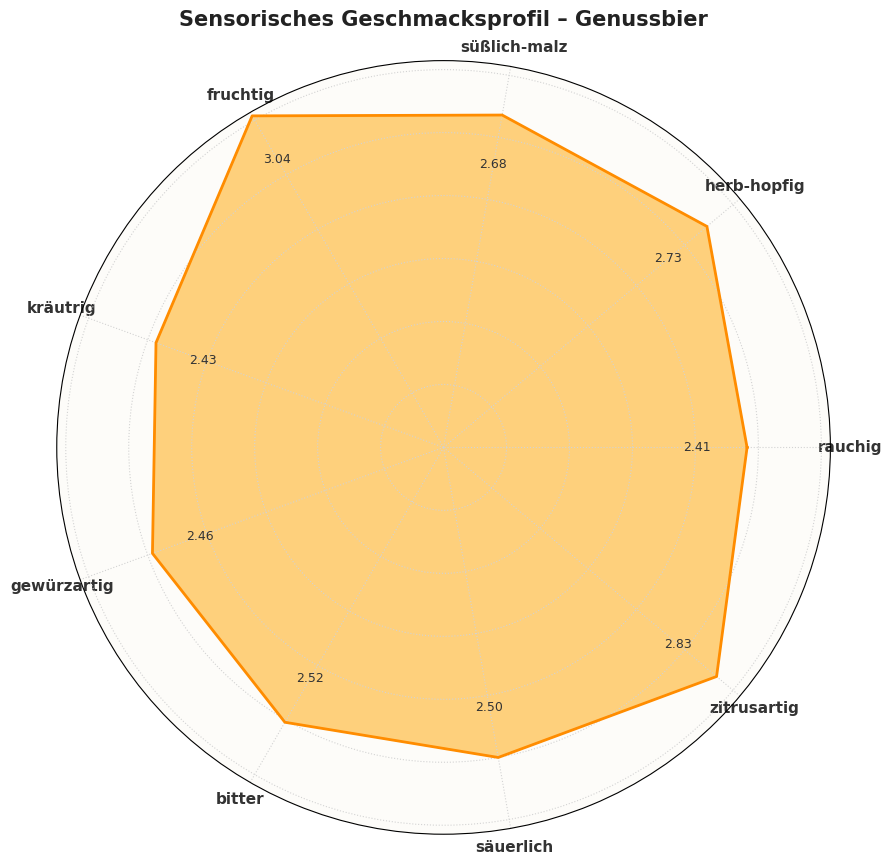

In [50]:
import numpy as np
import matplotlib.pyplot as plt

# Mittelwerte der Geschmacksfragen berechnen
df_geschmack = df[list(geschmacksfragen.keys())]
geschmackswerte = df_geschmack.mean().round(2)
geschmackswerte.index = [geschmacksfragen[q] for q in geschmackswerte.index]  # Achsenbeschriftungen

# Plot-Vorbereitung
labels = list(geschmackswerte.index)
values = list(geschmackswerte.values)

# Radar-Koordinaten vorbereiten
values += values[:1]  # Kreis schließen
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]

# Farbschema
line_color = '#FF8C00'        # Dunkles Orange
fill_color = '#FFA50080'      # Transparentes Orange (50%)

# Plot erstellen
fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))
ax.set_facecolor('#fdfcf9')  # Dezenter Hintergrund

# Radarlinien
ax.plot(angles, values, color=line_color, linewidth=2)
ax.fill(angles, values, color=fill_color)

# Achsenbeschriftungen
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=11, fontweight='bold', color='#333')

# Keine sichtbare Y-Achse
ax.set_yticklabels([])
ax.grid(color='lightgrey', linestyle='dotted', linewidth=0.8)

# Titel
ax.set_title("Sensorisches Geschmacksprofil – Genussbier", size=15, weight='bold', pad=25, color='#222')

# Werte innerhalb des Charts anzeigen
for angle, value in zip(angles[:-1], values[:-1]):
    ax.text(angle, value - 0.4, f"{value:.2f}", ha='center', va='center', fontsize=9, color='#333')

# Finalisieren
plt.tight_layout()
plt.savefig("geschmacksprofil_radar.png", dpi=300)
plt.show()

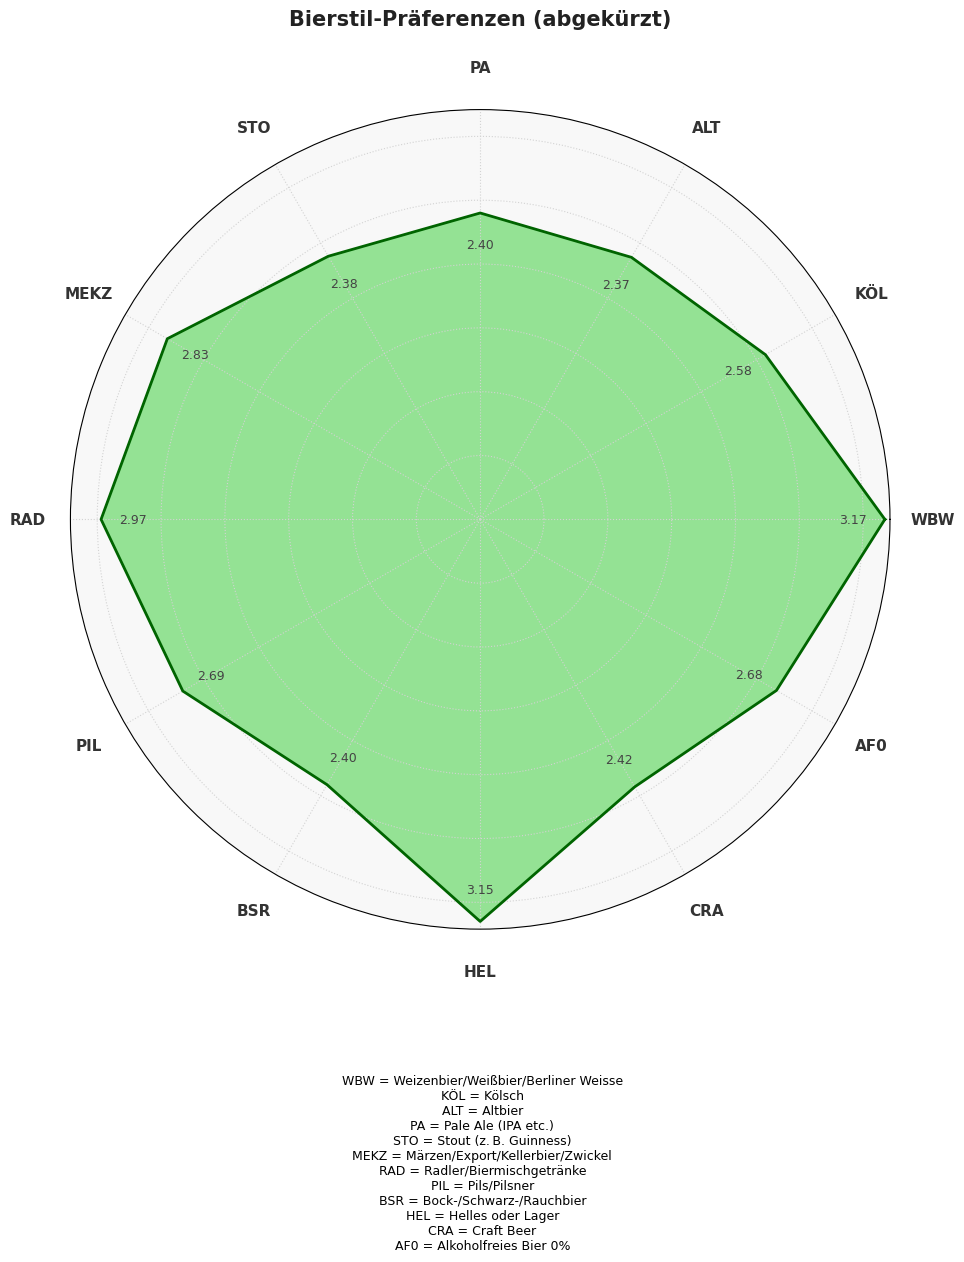

In [49]:
# Abkürzungen definieren
bierstilfragen = {
    "Q9B": "WBW",   # Weizenbier/Weißbier/Berliner Weisse
    "Q9C": "KÖL",   # Kölsch
    "Q9D": "ALT",   # Altbier
    "Q9E": "PA",    # Pale Ale
    "Q9F": "STO",   # Stout
    "Q9G": "MEKZ",  # Märzen/Export/Kellerbier/Zwickel
    "Q9H": "RAD",   # Radler/Biermischgetränke
    "Q9I": "PIL",   # Pils
    "Q9J": "BSR",   # Bock/Schwarzbier/Rauchbier
    "Q9K": "HEL",   # Helles oder Lager
    "Q9L": "CRA",   # Craft Beer
    "Q10A": "AF0",  # Alkoholfreies Bier 0%
}

bierstil_legende = {
    "WBW": "Weizenbier/Weißbier/Berliner Weisse",
    "KÖL": "Kölsch",
    "ALT": "Altbier",
    "PA": "Pale Ale (IPA etc.)",
    "STO": "Stout (z. B. Guinness)",
    "MEKZ": "Märzen/Export/Kellerbier/Zwickel",
    "RAD": "Radler/Biermischgetränke",
    "PIL": "Pils/Pilsner",
    "BSR": "Bock-/Schwarz-/Rauchbier",
    "HEL": "Helles oder Lager",
    "CRA": "Craft Beer",
    "AF0": "Alkoholfreies Bier 0%",
}

# Mittelwerte berechnen
df_bierstile = df[list(bierstilfragen.keys())]
bierstile_mw = df_bierstile.mean().round(2)
bierstile_mw.index = [bierstilfragen[q] for q in bierstile_mw.index]  # Kürzel verwenden

# Radar-Daten vorbereiten
labels = list(bierstile_mw.index)
values = list(bierstile_mw.values)
values += values[:1]
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]

# Farben und Stil
line_color = '#006400'
fill_color = '#32CD3280'

# Radar-Chart
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))
ax.set_facecolor('#f8f8f8')

ax.plot(angles, values, color=line_color, linewidth=2)
ax.fill(angles, values, color=fill_color)

# Beschriftung außen mit Abstand
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=11, fontweight='bold', color='#333')
ax.tick_params(axis='x', pad=20)

# Y-Achse ausblenden
ax.set_yticklabels([])
ax.grid(color='lightgrey', linestyle='dotted', linewidth=0.8)

# Titel
ax.set_title("Bierstil-Präferenzen (abgekürzt)", size=15, weight='bold', pad=25, color='#222')

# Werte direkt anzeigen
for angle, value in zip(angles[:-1], values[:-1]):
    ax.text(angle, value - 0.25, f"{value:.2f}", ha='center', va='center', fontsize=9, color='#444')

# Legende hinzufügen (außerhalb unterhalb)
legend_text = "\n".join([f"{k} = {v}" for k, v in bierstil_legende.items()])
plt.figtext(0.5, -0.08, legend_text, wrap=True, ha='center', va='top', fontsize=9)

# Layout und Export
plt.tight_layout()
plt.savefig("bierstile_radar_mit_legende.png", dpi=300, bbox_inches='tight')
plt.show()

In [35]:
# 7. Klartext-Fragen für jede Variable
fragen_dict = {
    "Q2C": "zuhause beim Essen",
    "Q2D": "zuhause zur Entspannung",
    "Q6C": "Es macht mir großen Spaß ein Bier oder bierhaltiges Getränk zu konsumieren.",
    "Q7A": "Gesunde Ernährung ist mir sehr wichtig.",
    "Q7C": "Ich probiere sehr gerne neue Produkte oder Geschmacksrichtungen aus.",
    "Q8A": "Geschmack des Getränks",
    "Q8B": "Geruch/Aroma des Getränks",
    "Q8C": "Kaufpreis des Getränks",
    "Q8E": "Nachhaltige Produktion des Getränks",
    "Q8G": "Design der Verpackung",
    "Q8J": "Alkoholgehalt des Getränks",
    "Q9A": "Alkoholfreies Bier oder alkoholfreie Biermischgetränke",
    "Q9B": "Weizenbier/Weißbier/Berliner Weisse",
    "Q9C": "Kölsch",
    "Q9D": "Altbier (bspw. Diebels)",
    "Q9E": "Pale Ale (IPA etc.)",
    "Q9F": "Stout (bspw. Guinness)",
    "Q9G": "Märzen/Export/Kellerbier/Zwickelbier",
    "Q9H": "Radler/Biermischgetränke (bspw. Cola-Bier)",
    "Q9I": "Pils/Pilsner",
    "Q9J": "Bockbier/Schwarzbier/Rauchbier (bspw. Köstritzer)",
    "Q9K": "Helles oder Lager (bspw. Augustiner)",
    "Q9L": "Craft Beer",
    "Q10A": "Alkoholfreies Bier ohne Alkohol (0% Alkoholgehalt)",
    "Q11A": "rauchiger Geschmack",
    "Q11B": "herber-hopfiger Geschmack",
    "Q11C": "süßlich-malziger Geschmack",
    "Q11D": "fruchtiger Geschmack",
    "Q11E": "Geschmack nach Kräutern",
    "Q11F": "Geschmack nach Gewürzen",
    "Q11G": "bitterer Geschmack",
    "Q11H": "säuerlicher Geschmack",
    "Q11I": "Zitrusgeschmack",
    "Q12G": "Verkaufsförderung/Angebote vor Ort im Handel"
}

# 8. Variablen umbenennen und sortiert ausgeben
means_named = means.rename(index=fragen_dict).sort_values(ascending=False)
means_named_df = means_named.reset_index()
means_named_df.columns = ["Frage", "Durchschnittlicher Wert"]

# 9. Ausgabe als sortierte Tabelle im Terminal
print(means_named_df.to_string(index=False))


                                                                      Frage  Durchschnittlicher Wert
                                                     Geschmack des Getränks                     3.63
       Ich probiere sehr gerne neue Produkte oder Geschmacksrichtungen aus.                     3.31
                                                     Kaufpreis des Getränks                     3.27
Es macht mir großen Spaß ein Bier oder bierhaltiges Getränk zu konsumieren.                     3.24
                                    Gesunde Ernährung ist mir sehr wichtig.                     3.22
                                                  Geruch/Aroma des Getränks                     3.22
                                        Weizenbier/Weißbier/Berliner Weisse                     3.17
                                       Helles oder Lager (bspw. Augustiner)                     3.15
                                                       fruchtiger Geschmack                

In [ ]:
from openai import OpenAI
import time

# 1. OpenAI-Client initialisieren (API-Key hier einfügen)
client = OpenAI(api_key="")

# 2. Prompt mit Skalen und Mittelwerten
genuss_prompt = """
Du bist Biersommelier:in und Spezialist:in für sensorische Konsumentenprofile.

Basierend auf den folgenden Mittelwerten aus einer Umfrage und den zugehörigen Antwortskalen, sollst du ein literarisches, aber fundiertes Sensorprofil eines innovativen „Genussbieres“ formulieren. Der Text soll sich lesen wie die Beschreibung eines sensorisch ausgereiften Produkts auf einem Bieretikett oder in einem Fachkatalog.

Bitte berücksichtige die Mittelwerte UND die Antwortskalen. Höhere Werte bedeuten tendenziell stärkere Zustimmung oder Präferenz. Der Text soll max. 300 Wörter lang sein.

### Mittelwerte & Skalen (repräsentative Auswahl):

Frage,Durchschnittlicher Wert,Antwortskala
Geschmack des Getränks,3.63,['sehr geringer Einfluss(1)', ..., 'sehr starker Einfluss(5)']
Ich probiere sehr gerne neue Produkte oder Geschmacksrichtungen aus.,3.31,['trifft überhaupt nicht zu(1)', ..., 'trifft voll und ganz zu(5)']
Kaufpreis des Getränks,3.27,['sehr geringer Einfluss(1)', ..., 'sehr starker Einfluss(5)']
Es macht mir großen Spaß ein Bier oder bierhaltiges Getränk zu konsumieren.,3.24,['trifft überhaupt nicht zu(1)', ..., 'trifft voll und ganz zu(5)']
Gesunde Ernährung ist mir sehr wichtig.,3.22,['trifft überhaupt nicht zu(1)', ..., 'trifft voll und ganz zu(5)']
Geruch/Aroma des Getränks,3.22,['sehr geringer Einfluss(1)', ..., 'sehr starker Einfluss(5)']
Weizenbier/Weißbier/Berliner Weisse,3.17,['sehr niedrige Präferenz(1)', ..., 'sehr hohe Präferenz(5)']
Helles oder Lager (bspw. Augustiner),3.15,keine Skala vorhanden
fruchtiger Geschmack,3.04,['sehr niedrige Präferenz(1)', ..., 'sehr hohe Präferenz(5)']
Radler/Biermischgetränke (bspw. Cola-Bier),2.97,['sehr niedrige Präferenz(1)', ..., 'sehr hohe Präferenz(5)']
Design der Verpackung,2.92,['sehr geringer Einfluss(1)', ..., 'sehr starker Einfluss(5)']
Zitrusgeschmack,2.83,['sehr niedrige Präferenz(1)', ..., 'sehr hohe Präferenz(5)']
Märzen/Export/Kellerbier/Zwickelbier,2.83,['sehr niedrige Präferenz(1)', ..., 'sehr hohe Präferenz(5)']
Alkoholgehalt des Getränks,2.81,['sehr geringer Einfluss(1)', ..., 'sehr starker Einfluss(5)']
herber-hopfiger Geschmack,2.73,['sehr niedrige Präferenz(1)', ..., 'sehr hohe Präferenz(5)']
Alkoholfreies Bier oder alkoholfreie Biermischgetränke,2.71,['sehr niedrige Präferenz(1)', ..., 'sehr hohe Präferenz(5)']
Pils/Pilsner,2.69,['sehr niedrige Präferenz(1)', ..., 'sehr hohe Präferenz(5)']
süßlich-malziger Geschmack,2.68,['sehr niedrige Präferenz(1)', ..., 'sehr hohe Präferenz(5)']
Alkoholfreies Bier ohne Alkohol (0% Alkoholgehalt),2.68,['sehr niedrige Präferenz(1)', ..., 'sehr hohe Präferenz(5)']
Verkaufsförderung/Angebote vor Ort im Handel,2.66,['gar nicht(1)', ..., 'sehr stark(5)']
Nachhaltige Produktion des Getränks,2.59,['sehr geringer Einfluss(1)', ..., 'sehr starker Einfluss(5)']
Kölsch,2.58,['sehr niedrige Präferenz(1)', ..., 'sehr hohe Präferenz(5)']
bitterer Geschmack,2.52,['sehr niedrige Präferenz(1)', ..., 'sehr hohe Präferenz(5)']
säuerlicher Geschmack,2.5,['sehr niedrige Präferenz(1)', ..., 'sehr hohe Präferenz(5)']
Geschmack nach Gewürzen,2.46,['sehr niedrige Präferenz(1)', ..., 'sehr hohe Präferenz(5)']
Geschmack nach Kräutern,2.43,['sehr niedrige Präferenz(1)', ..., 'sehr hohe Präferenz(5)']
Craft Beer,2.42,['sehr niedrige Präferenz(1)', ..., 'sehr hohe Präferenz(5)']
rauchiger Geschmack,2.41,['sehr niedrige Präferenz(1)', ..., 'sehr hohe Präferenz(5)']
Bockbier/Schwarzbier/Rauchbier (bspw. Köstritzer),2.4,['sehr niedrige Präferenz(1)', ..., 'sehr hohe Präferenz(5)']
Pale Ale (IPA etc.),2.4,['sehr niedrige Präferenz(1)', ..., 'sehr hohe Präferenz(5)']
Stout (bspw. Guinness),2.38,['sehr niedrige Präferenz(1)', ..., 'sehr hohe Präferenz(5)']
Altbier (bspw. Diebels),2.37,['sehr niedrige Präferenz(1)', ..., 'sehr hohe Präferenz(5)']
zuhause zur Entspannung,1.91,['nie(1)', 'gelegentlich(2)', 'häufig(3)']
zuhause beim Essen,1.91,['nie(1)', 'gelegentlich(2)', 'häufig(3)']

### Aufgabe:

Formuliere basierend auf den obigen Daten ein vollständiges sensorisches Textprofil des idealen Genussbieres. Kombiniere Werte sinnvoll (z. B. Geschmack + Fruchtigkeit + Aroma), aber erwähne keine Mittelwerte oder Skalen – nur das Ergebnis in Worten.
"""

# 3. Assistant erstellen
assistant = client.beta.assistants.create(
    name="GenussBierProfiler",
    instructions=(
        "Du bist ein erfahrener Biersommelier, spezialisiert auf die sensorische Beschreibung "
        "von neuen Biersorten. Dein Ziel ist es, aus Konsumenten-Umfragedaten ein professionelles "
        "Sensorprofil zu formulieren, das für Marketing, Etikettendesign und Innovationsentwicklung geeignet ist."
    ),
    model="gpt-4o"
)

# 4. Thread starten
thread = client.beta.threads.create()

# 5. Nachricht an den Thread senden
client.beta.threads.messages.create(
    thread_id=thread.id,
    role="user",
    content=genuss_prompt
)

# 6. Assistant starten
run = client.beta.threads.runs.create(
    thread_id=thread.id,
    assistant_id=assistant.id
)

# 7. Auf Fertigstellung warten
while True:
    run_status = client.beta.threads.runs.retrieve(thread_id=thread.id, run_id=run.id)
    if run_status.status == "completed":
        break
    elif run_status.status == "failed":
        raise Exception("Fehlgeschlagen.")
    time.sleep(1)

# 8. Ausgabe anzeigen
messages = client.beta.threads.messages.list(thread_id=thread.id)
for message in messages.data:
    if message.role == "assistant":
        print("\n🟢 Sensorprofil Genussbier:\n")
        print(message.content[0].text.value)


/var/folders/vb/3fgx1mm954q9j0shqmng75q00000gn/T/ipykernel_54561/206005989.py:70: DeprecationWarning: The Assistants API is deprecated in favor of the Responses API
  thread = client.beta.threads.create()
/var/folders/vb/3fgx1mm954q9j0shqmng75q00000gn/T/ipykernel_54561/206005989.py:73: DeprecationWarning: The Assistants API is deprecated in favor of the Responses API
  client.beta.threads.messages.create(
/var/folders/vb/3fgx1mm954q9j0shqmng75q00000gn/T/ipykernel_54561/206005989.py:80: DeprecationWarning: The Assistants API is deprecated in favor of the Responses API
  run = client.beta.threads.runs.create(
/var/folders/vb/3fgx1mm954q9j0shqmng75q00000gn/T/ipykernel_54561/206005989.py:87: DeprecationWarning: The Assistants API is deprecated in favor of the Responses API
  run_status = client.beta.threads.runs.retrieve(thread_id=thread.id, run_id=run.id)
/var/folders/vb/3fgx1mm954q9j0shqmng75q00000gn/T/ipykernel_54561/206005989.py:95: DeprecationWarning: The Assistants API is deprecated 


🟢 Sensorprofil Genussbier:

Erleben Sie die meisterhafte Komposition des Genussbieres, ein harmonisches Werk für den anspruchsvollen Gaumen. Diese erlesene Kreation entfesselt einen ausgewogenen Geschmack, der sanft auf der Zunge zergeht. Lassen Sie sich verführen von dezenten, aber bereichernden fruchtigen Akzenten und einer subtilen, malzigen Süße, die sich wohltuend im Hintergrund entfalten.

Das Aromaprofil dieses Bieres umhüllt Sie mit einer feinen Melange aus blumigen und leicht zitrischen Nuancen, die den Geruchssinn anregen und das Verlangen nach einem weiteren Schluck wecken. Harmonisch unterstützt wird dieses Bouquet durch den zarten, unwiderstehlichen Hauch von Weizen, der an laue Sommerabende erinnert.

Bei der Entwicklung dieses Bieres wurde besonderes Augenmerk auf die geschmackliche Balance gelegt. Der Alkoholgehalt verweilt im Hintergrund, um den vollen Genuss nicht zu überlagern, sondern perfekt zu begleiten. Noten von Hopfen ergänzen das Geschmacksbild durch ihre san

In [ ]:
# 9. Extrahiere den Sensorprofil-Text (letzte Assistent-Antwort)
sensorprofil_text = ""
for message in messages.data:
    if message.role == "assistant":
        sensorprofil_text = message.content[0].text.value
        break

# 10. Brauerorientierter Prompt – Bierstil, Geschmack, Rezeptidee
produkt_prompt = f"""
Hier ist das sensorische Textprofil eines Konsumenten-orientierten Genussbieres:

{sensorprofil_text}

Auf dieser Basis sollst du als Biersommelier und Brau-Expert:in ein realisierbares, innovatives Bierkonzept vorschlagen.

Bitte beschreibe konkret und sachlich:
1. Den **Namen** des Bieres (kreativ und markentauglich)
2. **Empfohlener Bierstil** (z. B. Pale Ale, Fruchtweizen, Infused Helles)
3. **Sensorisches Geschmacksprofil des fertigen Bieres**
   - Bitterkeit (z. B. IBU-Bereich)
   - Fruchtcharakter (z. B. Mango, Mandarine, Zitrone – natürlich oder Hopfen-induziert)
   - Malzcharakter (z. B. süßlich, trocken, karamellig)
   - Säure, Würze, Kräuternoten etc.
4. **Zutatenempfehlung** (z. B. Hopfensorten, Hefestil, mögliche Fruchtinfusionen)
5. **Empfohlener Alkoholgehalt (in Vol.%)**

Keine Werbesprache. Ziel ist ein **technisch präzises Innovationsprofil**, das eine Brauerei direkt umsetzen kann.
"""

# 11. Neue Nachricht an denselben Thread senden
client.beta.threads.messages.create(
    thread_id=thread.id,
    role="user",
    content=produkt_prompt
)

# 12. Neuen Run starten für die Produktentwicklung
run2 = client.beta.threads.runs.create(
    thread_id=thread.id,
    assistant_id=assistant.id
)

# 13. Auf die neue Antwort warten
while True:
    run_status2 = client.beta.threads.runs.retrieve(thread_id=thread.id, run_id=run2.id)
    if run_status2.status == "completed":
        break
    elif run_status2.status == "failed":
        raise Exception("Produktentwicklung fehlgeschlagen.")
    time.sleep(1)

# 14. Ausgabe des konkreten Bierprodukts anzeigen
# Nur die neueste Antwort vom Assistant auslesen
latest_message = messages.data[0]  # neueste Nachricht ist immer an erster Stelle

if latest_message.role == "assistant":
    print("\n🟢 Konkretes Bierkonzept für die Brauerei:\n")
    print(latest_message.content[0].text.value)


/var/folders/vb/3fgx1mm954q9j0shqmng75q00000gn/T/ipykernel_54561/3908865989.py:31: DeprecationWarning: The Assistants API is deprecated in favor of the Responses API
  client.beta.threads.messages.create(
/var/folders/vb/3fgx1mm954q9j0shqmng75q00000gn/T/ipykernel_54561/3908865989.py:38: DeprecationWarning: The Assistants API is deprecated in favor of the Responses API
  run2 = client.beta.threads.runs.create(
/var/folders/vb/3fgx1mm954q9j0shqmng75q00000gn/T/ipykernel_54561/3908865989.py:45: DeprecationWarning: The Assistants API is deprecated in favor of the Responses API
  run_status2 = client.beta.threads.runs.retrieve(thread_id=thread.id, run_id=run2.id)
/var/folders/vb/3fgx1mm954q9j0shqmng75q00000gn/T/ipykernel_54561/3908865989.py:53: DeprecationWarning: The Assistants API is deprecated in favor of the Responses API
  messages2 = client.beta.threads.messages.list(thread_id=thread.id)



🍺 Konkretes Bierprodukt basierend auf dem Sensorprofil:

**1. Name des Bieres:**  
"Sommermelodie"

**2. Empfohlener Bierstil:**  
Fruchtweizenbier

**3. Sensorisches Geschmacksprofil des fertigen Bieres:**

- **Bitterkeit:**  
  15–20 IBU. Diese moderate Bitterkeit unterstützt den fruchtig-frischen Charakter, ohne ihn zu überlagern.

- **Fruchtcharakter:**  
  Der Fruchtcharakter wird durch natürliche Aromen von Mandarine und Zitrone bestimmt, die während der Gärung durch Zugabe von Schalen oder Zesten verstärkt werden. Zusätzlich hinzugefügte Hopfen wie Mandarina Bavaria und Citra akzentuieren diese Noten.

- **Malzcharakter:**  
  Leicht süßlicher Malzcharakter mit einem Hauch von Karamell, um die Fruchtnoten zu unterstützen und eine angenehme Tiefe zu verleihen. Die Basis bildet ein Weizen- und Pilsner Malzprofil.

- **Säure, Würze, Kräuternoten etc.:**  
  Eine leichte, natürliche Säure verstärkt die Frische des Bieres. Dezente Gewürznoten, eventuell durch Koriandersamen oder Ora